In [1]:
import polars as pl

In [2]:
ruta_parquet_tomtom = 'data/raw/tomtom_move_reports/segments_1_to_31_aug_2024.parquet'
df_tomtom_lazy = pl.scan_parquet(ruta_parquet_tomtom)

df_tomtom = df_tomtom_lazy.collect()

In [3]:
df_tomtom

date,station_id,station_name,segment_id,new_segment_id,frc,street_name,distance_m,time_set_id,hour_start,hour_end,harmonic_avg_speed,median_speed,avg_speed,std_speed,travel_time_std,sample_size,normalized_sample_size,avg_travel_time,median_travel_time,travel_time_ratio,speed_percentiles,geometry_wkt
str,i64,str,i64,str,i64,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,list[i64],str
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,2,0,1,23.6,24.7,24.3,3.9,2.56,9,0.0059,12.53,11.95,1.0,"[16, 16, … 29]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,3,1,2,26.6,25.6,28.6,8.2,3.02,10,0.0065,11.1,11.53,0.89,"[19, 19, … 44]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,4,2,3,25.8,28.2,29.3,10.3,4.96,8,0.0052,11.45,10.47,0.91,"[13, 13, … 47]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,5,3,4,9.4,9.4,9.4,0.0,0.0,1,0.0007,31.41,31.41,2.51,"[9, 9, … 9]","""LINESTRING (-100.3201 25.66233…"
"""2024-08-01""",0,"""CENTRO""",-14840000675661,"""-00004d30-3900-0400-0000-00000…",5,"""Calle Tlaxcala""",82.01,6,4,5,18.2,17.2,18.7,4.0,3.15,3,0.002,16.23,17.16,1.3,"[16, 16, … 23]","""LINESTRING (-100.3201 25.66233…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,21,19,20,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,22,20,21,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"
"""2024-08-31""",2,"""NORTE""",14840013639640,"""fff1bf1d-0d5d-4af5-bbc8-101508…",7,null,153.51,23,21,22,0.0,0.0,0.0,null,null,0,0.0,0.0,0.0,0.0,"[0, 0, … 0]","""LINESTRING (-100.34139 25.7849…"


In [4]:

MIN_SAMPLE_SIZE = 10
MAX_FRC_PRINCIPAL = 4

required_cols = ["station_name", "date", "street_name", "hour_start", "travel_time_ratio", "sample_size", "frc", "harmonic_avg_speed", "distance_m", "travel_time_std"]

_df = df_tomtom.filter(
    (pl.col("frc") <= MAX_FRC_PRINCIPAL)
    & (pl.col("sample_size") >= MIN_SAMPLE_SIZE)
)

# agregar por estación/calle/hora/fecha
_df = (
    _df.group_by(["station_name", "street_name", "hour_start", "date"])
    .agg([
        (
            (pl.col("harmonic_avg_speed").cast(pl.Float64) * pl.col("distance_m").cast(pl.Float64)).sum()
            / pl.col("distance_m").cast(pl.Float64).sum()
        ).alias("weighted_harmonic_speed"),
        pl.col("travel_time_ratio").mean().alias("avg_tti_street"),
        pl.col("sample_size").sum().alias("total_sample_size"),
        pl.col("travel_time_std").mean().alias("avg_travel_time_std"),
        pl.col("distance_m").sum().alias("distance_sum_m"),
    ])
    .sort(["date", "station_name", "street_name", "hour_start"])
)

df_tomtom_clean_eda = _df

In [5]:
ruta_csv_sima = "data/processed/df_imputados_unidades_saits_agosto2024_schema.csv"
df_sima = pl.read_csv(ruta_csv_sima)
# filtrar a solo agosto
df_sima = df_sima.filter(
    pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").dt.month() == 8,
     pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").dt.year() == 2024
)

df_sima = df_sima.with_columns(
    pl.col("date").str.to_datetime(format="%Y-%m-%d %H:%M:%S").alias("date")
)
df_sima  = df_sima.with_columns(
    pl.col("date").dt.date().cast(pl.Utf8).alias("date_only")
)
df_sima = df_sima[['date_only', 'Hora', 'Zona', 'CO', 'NOX', 'O3', 'PM2.5', 'PM10', 'WSR', 'WDR']]

df_sima

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10,WSR,WDR
str,i64,str,f64,f64,f64,f64,f64,f64,f64
"""2024-08-01""",0,"""CENTRO""",0.4841826,8.767834,16.384539,32.805374,88.79609,9.015996,85.00341
"""2024-08-01""",0,"""NORTE""",0.9056643,8.050037,13.299111,22.510893,78.0,9.597399,171.84186
"""2024-08-01""",0,"""SURESTE""",0.623575,7.507266,18.192194,22.631094,91.57979,15.822094,110.56041
"""2024-08-01""",1,"""CENTRO""",0.58,15.6,13.0,39.149998,94.0,8.0,47.999996
"""2024-08-01""",1,"""NORTE""",0.9464729,7.5113125,14.000001,20.661089,69.0,7.2000003,150.0
…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",1.409713,24.199999,16.0,18.409334,25.999998,4.7,81.0
"""2024-08-31""",22,"""SURESTE""",1.54,45.5,4.0,6.6899986,42.0,4.2999997,159.0
"""2024-08-31""",23,"""CENTRO""",1.1500001,20.1,12.000002,13.86,36.0,3.8,86.0


In [6]:
FRC_to_lanes = {
    0: 3,
    1: 2,
    2: 2,
    3: 2,
    4: 1,
    5: 1,
    6: 1,
    7: 1,
}

df_tomtom = df_tomtom[['date', 'hour_start', 'station_name', 'segment_id', 'street_name', 'sample_size', 'travel_time_ratio', 'frc', 'avg_speed', 'distance_m', 'geometry_wkt']]

JAM_DENSITY_PER_LANE = 150

df_tomtom_vci_per_segment = (
    df_tomtom
    .with_columns(
        pl.col("frc").replace(FRC_to_lanes).alias("lanes")
    )
    .with_columns(
        pl.col("avg_speed").max().over("date").alias("free_flow_speed")
    )
    .with_columns(
        (JAM_DENSITY_PER_LANE * (1 - pl.col("avg_speed") / pl.col("free_flow_speed")))
        .alias("est_density_per_lane")
    )
    .with_columns(
        (pl.col("est_density_per_lane") * pl.col("lanes")).alias("est_density_total")
    )
    .with_columns(
        (pl.col("distance_m") / 1000).alias("distance_km")
    )
    .with_columns(
        (pl.col("est_density_total") * pl.col("distance_km"))
        .alias("estimated_vehicles_in_segment")
    )
    .with_columns(
        (pl.col("est_density_total") / (JAM_DENSITY_PER_LANE * pl.col("lanes")))
        .alias("congestion_ratio")
    ).with_columns(
        pl.col("geometry_wkt").alias("geometry_wkt")
    )
)

In [7]:
import polars as pl
import math
import re

_wkt_num = re.compile(r"-?\d+(?:\.\d+)?")

def wkt_centroid_latlon(wkt: str):
    """Centroid rápido [lat, lon] para LINESTRING WKT (lon lat pares)."""
    if wkt is None:
        return [None, None]
    nums = [float(x) for x in _wkt_num.findall(wkt)]
    if len(nums) < 4:
        return [None, None]
    lons = nums[0::2]
    lats = nums[1::2]
    return [sum(lats) / len(lats), sum(lons) / len(lons)]

station_coords = pl.DataFrame({
    "station_name": ["CENTRO", "SURESTE", "NORTE"],
    "station_lat":  [25.675833, 25.665278, 25.798611],
    "station_lon":  [-100.338333, -100.243611, -100.327222],
})

# --- preparar tablas base ---
df_seg = df_tomtom_vci_per_segment.with_columns([
    pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).alias("date"),
    pl.col("hour_start").cast(pl.Int64).alias("hour"),
])

df_sima_wind = (
    df_sima.select(["Zona", "date_only", "Hora", "WSR", "WDR"])
    .rename({"Zona": "station_name", "date_only": "date", "Hora": "hour"})
    .with_columns([
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d", strict=False).alias("date"),
        pl.col("hour").cast(pl.Int64).alias("hour"),
    ])
)


DEG2RAD = math.pi / 180.0
R_EARTH = 6_371_000.0
u_min = 0.5
crosswind_max_deg = 70
L = 3000.0
A_Y, B_Y = 6.5, 0.80
A_Z, B_Z = 6.0, 0.8


df = (
    df_seg
    .join(station_coords, on="station_name", how="left")
    .join(df_sima_wind, on=["station_name", "date", "hour"], how="left")
    .with_columns(
        pl.col("geometry_wkt")
          .map_elements(wkt_centroid_latlon, return_dtype=pl.List(pl.Float64))
          .alias("seg_latlon")
    )
    .with_columns([
        pl.col("seg_latlon").list.get(0).alias("seg_lat"),
        pl.col("seg_latlon").list.get(1).alias("seg_lon"),
        # proxy de emisión: autos estimados * congestión (mantener >0)
        (
            pl.col("estimated_vehicles_in_segment")
            * (pl.col("congestion_ratio").clip(lower_bound=0.0) + 0.05)
        ).alias("Q_hat"),
    ])
)


df = df.with_columns([
    pl.when(pl.col("WSR").is_null())
      .then(None)
      .when(pl.col("WSR") < u_min).then(u_min)
      .otherwise(pl.col("WSR")).alias("u"),
    ((pl.col("WDR") + 180.0) % 360.0).alias("wind_to_deg"),
    (pl.col("WDR").is_not_null()).alias("has_wind"),
])


df = df.with_columns([
    (pl.col("wind_to_deg") * DEG2RAD).alias("theta"),
    ((pl.col("station_lat") - pl.col("seg_lat")) * DEG2RAD).alias("dlat"),
    ((pl.col("station_lon") - pl.col("seg_lon")) * DEG2RAD).alias("dlon"),
    (((pl.col("station_lat") + pl.col("seg_lat")) / 2.0) * DEG2RAD).alias("lat_mean"),
])

df = df.with_columns([
    (R_EARTH * pl.col("dlat")).alias("dy_north_m"),
    (R_EARTH * pl.col("lat_mean").cos() * pl.col("dlon")).alias("dx_east_m"),
])

df = df.with_columns([
    (pl.col("dx_east_m")**2 + pl.col("dy_north_m")**2).sqrt().alias("dist_m"),
    (
        pl.col("dx_east_m") * pl.col("theta").sin()
        + pl.col("dy_north_m") * pl.col("theta").cos()
    ).alias("x_downwind_m"),
    (
        pl.col("dx_east_m") * pl.col("theta").cos()
        - pl.col("dy_north_m") * pl.col("theta").sin()
    ).alias("y_crosswind_m"),
])


df = df.with_columns([
    pl.when(pl.col("x_downwind_m") > 0)
      .then(A_Y * (pl.col("x_downwind_m") + 1.0) ** B_Y)
      .otherwise(None)
      .alias("sigma_y"),
    pl.when(pl.col("x_downwind_m") > 0)
      .then(A_Z * (pl.col("x_downwind_m") + 1.0) ** B_Z)
      .otherwise(None)
      .alias("sigma_z"),
])


crosswind_limit = (pl.col("x_downwind_m") * math.tan(math.radians(crosswind_max_deg))).abs()

df = df.with_columns([
    pl.when(
        (pl.col("x_downwind_m") > 0)
        & (pl.col("sigma_y").is_not_null())
        & (pl.col("u").is_not_null())
        & (pl.col("y_crosswind_m").abs() <= crosswind_limit)
    ).then(
        pl.col("Q_hat")
        * (-(pl.col("y_crosswind_m")**2) / (2.0 * pl.col("sigma_y")**2)).exp()
        * (-(pl.col("x_downwind_m") / L)).exp()
        / pl.col("u")
    ).otherwise(0.0).alias("influence_plume")
])

df = df.with_columns([
    (pl.col("influence_plume") + 1.0).log().alias("influence_plume_log1p")
])


preview_cols = [
    "station_name", "date", "hour", "segment_id", "WSR", "WDR",
    "dist_m", "x_downwind_m", "y_crosswind_m", "Q_hat", "influence_plume"
]
df.select([c for c in preview_cols if c in df.columns]).head(10)


station_name,date,hour,segment_id,WSR,WDR,dist_m,x_downwind_m,y_crosswind_m,Q_hat,influence_plume
str,date,i64,i64,f64,f64,f64,f64,f64,f64,f64
"""CENTRO""",2024-08-01,0,-14840000675661,9.015996,85.00341,2339.668114,1700.882843,1606.562926,9.347755,0.478271
"""CENTRO""",2024-08-01,1,-14840000675661,8.0,47.999996,2339.668114,391.394287,2306.698375,8.776152,0.0
"""CENTRO""",2024-08-01,2,-14840000675661,7.6,16.0,2339.668114,-890.442575,2163.598601,8.684805,0.0
"""CENTRO""",2024-08-01,3,-14840000675661,5.3,47.0,2339.668114,351.0774,2313.177802,11.467806,0.0
"""CENTRO""",2024-08-01,4,-14840000675661,3.1,23.0,2339.668114,-620.12901,2255.989117,10.119179,0.0
"""CENTRO""",2024-08-01,5,-14840000675661,5.2,53.999996,2339.668114,630.365825,2253.150197,9.293823,0.0
"""CENTRO""",2024-08-01,6,-14840000675661,5.7,65.0,2339.668114,1048.705701,2091.473939,9.173045,0.53103
"""CENTRO""",2024-08-01,7,-14840000675661,6.7,69.0,2339.668114,1192.044953,2013.225202,9.334257,0.527859
"""CENTRO""",2024-08-01,8,-14840000675661,7.1,68.0,2339.668114,1156.727774,2033.722631,9.199816,0.477024


In [8]:
df_tomtom_ip_hourly = (
    df
    .group_by(["date", "hour", "station_name"])
    .agg([
        pl.col("influence_plume").sum().alias("influence_plume_sum"),
        pl.col("influence_plume_log1p").sum().alias("influence_plume_log1p_sum"),
        pl.col("Q_hat").mean().alias("Q_hat_mean"),
        pl.col("u").mean().alias("u_mean"),
        pl.col("has_wind").mean().alias("wind_cov")
    ])
    .with_columns([
        ((pl.col("influence_plume_sum") - pl.col("influence_plume_sum").mean().over("station_name"))
         / pl.col("influence_plume_sum").std().over("station_name")).alias("influence_plume_z"),
    ])
    .sort(["station_name", "date", "hour"])
)

df_tomtom_ip_hourly


date,hour,station_name,influence_plume_sum,influence_plume_log1p_sum,Q_hat_mean,u_mean,wind_cov,influence_plume_z
date,i64,str,f64,f64,f64,f64,f64,f64
2024-08-01,0,"""CENTRO""",1799.904498,1369.525861,7.439061,9.015996,1.0,-0.44696
2024-08-01,1,"""CENTRO""",2166.854644,1598.484372,7.649177,8.0,1.0,-0.253922
2024-08-01,2,"""CENTRO""",2627.737088,1891.743747,7.773657,7.6,1.0,-0.011469
2024-08-01,3,"""CENTRO""",3447.646593,2257.887538,7.899069,5.3,1.0,0.419855
2024-08-01,4,"""CENTRO""",6376.178355,3486.237327,7.907991,3.1,1.0,1.960446
…,…,…,…,…,…,…,…,…
2024-08-31,19,"""SURESTE""",2514.325943,1665.548985,8.493598,6.4999995,1.0,-0.172982
2024-08-31,20,"""SURESTE""",5269.3621,2955.418192,8.495583,3.8,1.0,1.119362
2024-08-31,21,"""SURESTE""",3570.933849,1909.875272,8.518524,3.699999,1.0,0.322656


In [9]:
df_sima

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10,WSR,WDR
str,i64,str,f64,f64,f64,f64,f64,f64,f64
"""2024-08-01""",0,"""CENTRO""",0.4841826,8.767834,16.384539,32.805374,88.79609,9.015996,85.00341
"""2024-08-01""",0,"""NORTE""",0.9056643,8.050037,13.299111,22.510893,78.0,9.597399,171.84186
"""2024-08-01""",0,"""SURESTE""",0.623575,7.507266,18.192194,22.631094,91.57979,15.822094,110.56041
"""2024-08-01""",1,"""CENTRO""",0.58,15.6,13.0,39.149998,94.0,8.0,47.999996
"""2024-08-01""",1,"""NORTE""",0.9464729,7.5113125,14.000001,20.661089,69.0,7.2000003,150.0
…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",1.409713,24.199999,16.0,18.409334,25.999998,4.7,81.0
"""2024-08-31""",22,"""SURESTE""",1.54,45.5,4.0,6.6899986,42.0,4.2999997,159.0
"""2024-08-31""",23,"""CENTRO""",1.1500001,20.1,12.000002,13.86,36.0,3.8,86.0


In [10]:
df_tomtom_ip_hourly = df_tomtom_ip_hourly.with_columns([
    pl.col("date").dt.strftime("%Y-%m-%d").alias("date_str"),
    pl.col("hour").alias("hour_start")
])
df_tomtom_ip_hourly

date,hour,station_name,influence_plume_sum,influence_plume_log1p_sum,Q_hat_mean,u_mean,wind_cov,influence_plume_z,date_str,hour_start
date,i64,str,f64,f64,f64,f64,f64,f64,str,i64
2024-08-01,0,"""CENTRO""",1799.904498,1369.525861,7.439061,9.015996,1.0,-0.44696,"""2024-08-01""",0
2024-08-01,1,"""CENTRO""",2166.854644,1598.484372,7.649177,8.0,1.0,-0.253922,"""2024-08-01""",1
2024-08-01,2,"""CENTRO""",2627.737088,1891.743747,7.773657,7.6,1.0,-0.011469,"""2024-08-01""",2
2024-08-01,3,"""CENTRO""",3447.646593,2257.887538,7.899069,5.3,1.0,0.419855,"""2024-08-01""",3
2024-08-01,4,"""CENTRO""",6376.178355,3486.237327,7.907991,3.1,1.0,1.960446,"""2024-08-01""",4
…,…,…,…,…,…,…,…,…,…,…
2024-08-31,19,"""SURESTE""",2514.325943,1665.548985,8.493598,6.4999995,1.0,-0.172982,"""2024-08-31""",19
2024-08-31,20,"""SURESTE""",5269.3621,2955.418192,8.495583,3.8,1.0,1.119362,"""2024-08-31""",20
2024-08-31,21,"""SURESTE""",3570.933849,1909.875272,8.518524,3.699999,1.0,0.322656,"""2024-08-31""",21


In [11]:
df_sima_union_candidato = df_sima.join(
    df_tomtom_ip_hourly,
    left_on=['date_only', 'Hora', 'Zona'],
    right_on=['date_str', 'hour_start', 'station_name'],
    how='left'
)

df_sima_union_candidato

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10,WSR,WDR,date,hour,influence_plume_sum,influence_plume_log1p_sum,Q_hat_mean,u_mean,wind_cov,influence_plume_z
str,i64,str,f64,f64,f64,f64,f64,f64,f64,date,i64,f64,f64,f64,f64,f64,f64
"""2024-08-01""",0,"""CENTRO""",0.4841826,8.767834,16.384539,32.805374,88.79609,9.015996,85.00341,2024-08-01,0,1799.904498,1369.525861,7.439061,9.015996,1.0,-0.44696
"""2024-08-01""",0,"""NORTE""",0.9056643,8.050037,13.299111,22.510893,78.0,9.597399,171.84186,2024-08-01,0,2960.112531,2179.32585,9.054448,9.597399,1.0,-0.393152
"""2024-08-01""",0,"""SURESTE""",0.623575,7.507266,18.192194,22.631094,91.57979,15.822094,110.56041,2024-08-01,0,1497.123974,1214.496418,8.668409,15.822094,1.0,-0.650135
"""2024-08-01""",1,"""CENTRO""",0.58,15.6,13.0,39.149998,94.0,8.0,47.999996,2024-08-01,1,2166.854644,1598.484372,7.649177,8.0,1.0,-0.253922
"""2024-08-01""",1,"""NORTE""",0.9464729,7.5113125,14.000001,20.661089,69.0,7.2000003,150.0,2024-08-01,1,3984.639315,2744.413444,9.117754,7.2000003,1.0,-0.124785
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",1.409713,24.199999,16.0,18.409334,25.999998,4.7,81.0,2024-08-31,22,5041.139547,3031.924727,8.854241,4.7,1.0,0.151958
"""2024-08-31""",22,"""SURESTE""",1.54,45.5,4.0,6.6899986,42.0,4.2999997,159.0,2024-08-31,22,3412.340115,1993.600136,8.502695,4.2999997,1.0,0.248262
"""2024-08-31""",23,"""CENTRO""",1.1500001,20.1,12.000002,13.86,36.0,3.8,86.0,2024-08-31,23,4157.379167,2562.11152,7.351705,3.8,1.0,0.793219


In [12]:
cov = (
    df
    .group_by(["station_name", "date", "hour"])
    .agg(pl.col("has_wind").mean().alias("wind_cov"))
    .group_by("station_name")
    .agg([
        pl.col("wind_cov").mean().alias("wind_cov_mean"),
        pl.count().alias("n_hours"),
    ])
)
print(cov)


shape: (3, 3)
┌──────────────┬───────────────┬─────────┐
│ station_name ┆ wind_cov_mean ┆ n_hours │
│ ---          ┆ ---           ┆ ---     │
│ str          ┆ f64           ┆ u32     │
╞══════════════╪═══════════════╪═════════╡
│ NORTE        ┆ 1.0           ┆ 744     │
│ SURESTE      ┆ 1.0           ┆ 744     │
│ CENTRO       ┆ 1.0           ┆ 744     │
└──────────────┴───────────────┴─────────┘


/tmp/ipykernel_16458/1088815207.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_hours"),


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_candidate_v_contaminant(df ,candidate, contaminant):
    plt.figure(figsize=(10, 6))
    sns.regplot(
        x=candidate,
        y=contaminant,
        data=df.to_pandas(),
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red', 'lw': 2}
    )
    mean_contaminant = df[contaminant].mean()
    plt.axhline(
        y=mean_contaminant,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f'Media de {contaminant}: {mean_contaminant:.2f}'
    )
    plt.title(f'Scatterplot de {candidate} vs {contaminant} en {df["Zona"][0]}')
    plt.xlabel(candidate)
    plt.ylabel(contaminant)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_centros_candidate_v_contamintant(df, candidate, contaminant):
    for zona in ["NORTE", "SURESTE", "CENTRO"]:
        df_z = df.filter(pl.col('Zona') == zona)
        if df_z.height == 0:
            print(f"Sin datos para {zona}")
            continue
        plot_candidate_v_contaminant(df_z, candidate, contaminant)

def quick_corr(df, candidate, contaminant):
    sub = df.select([candidate, contaminant]).drop_nulls()
    n = sub.height
    if n < 10:
        print(f"{contaminant}: pocos datos ({n})")
        return
    pdf = sub.to_pandas()
    x = pdf[candidate].to_numpy()
    y = pdf[contaminant].to_numpy()
    if x.std(ddof=1) == 0:
        print(f"{contaminant}: varianza cero en {candidate}")
        return
    corr = np.corrcoef(x, y)[0, 1]
    cov = np.cov(x, y, ddof=1)[0, 1]
    var = x.var(ddof=1)
    mean_x = x.mean()
    mean_y = y.mean()
    slope = cov / var if var else 0
    intercept = mean_y - slope * mean_x
    print(f"{contaminant}: r={corr:.3f}, slope={slope:.5f}, intercept={intercept:.3f}, n={n}")

# Ejemplo de evaluación rápida
for contam in ["NOX", "PM2.5", "O3", "CO", "PM10"]:
    quick_corr(df_sima_union_candidato, "influence_plume_z", contam)

plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'influence_plume_z', 'NOX')


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_candidate_v_contaminant(df ,candidate, contaminant):

    plt.figure(figsize=(10, 6))

    sns.regplot(
        x=candidate,
        y=contaminant,
        data=df.to_pandas(),
        scatter_kws={'alpha': 0.5},
        line_kws={'color': 'red', 'lw': 2}
    )

    mean_contaminant = df[contaminant].mean()

    plt.axhline(
        y=mean_contaminant,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f'Media de {contaminant}: {mean_contaminant:.2f}'
    )

    plt.title(f'Scatterplot de {candidate} vs {contaminant} en {df["Zona"][0]}')
    plt.xlabel(candidate)
    plt.ylabel(contaminant)
    plt.legend()
    plt.grid(True)

    plt.show()

def plot_centros_candidate_v_contamintant(df, candidate, contaminant):
    df_sima_union_candidato_norte = df.filter(pl.col('Zona') == "NORTE")
    df_sima_union_candidato_sureste = df.filter(pl.col('Zona') == "SURESTE")
    df_sima_union_candidato_centro = df.filter(pl.col('Zona') == "CENTRO")
    plot_candidate_v_contaminant(df_sima_union_candidato_norte, candidate, contaminant)
    plot_candidate_v_contaminant(df_sima_union_candidato_sureste, candidate, contaminant)
    plot_candidate_v_contaminant(df_sima_union_candidato_centro, candidate, contaminant)

In [14]:
df_sima_union_candidato.columns

['date_only',
 'Hora',
 'Zona',
 'CO',
 'NOX',
 'O3',
 'PM2.5',
 'PM10',
 'WSR',
 'WDR',
 'date',
 'hour',
 'influence_plume_sum',
 'influence_plume_log1p_sum',
 'Q_hat_mean',
 'u_mean',
 'wind_cov',
 'influence_plume_z']

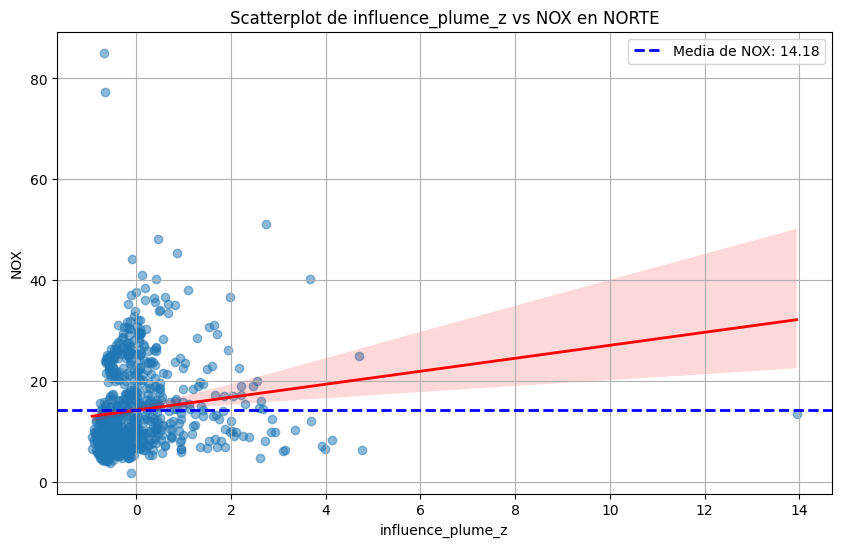

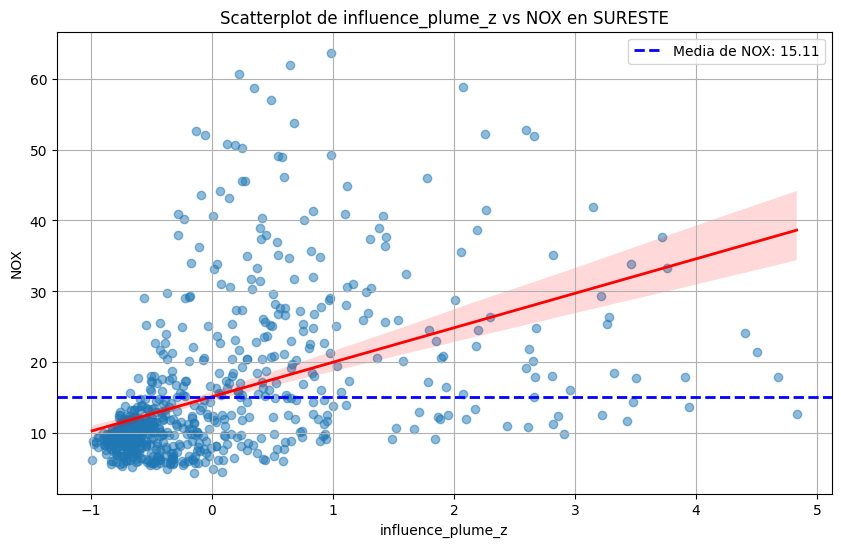

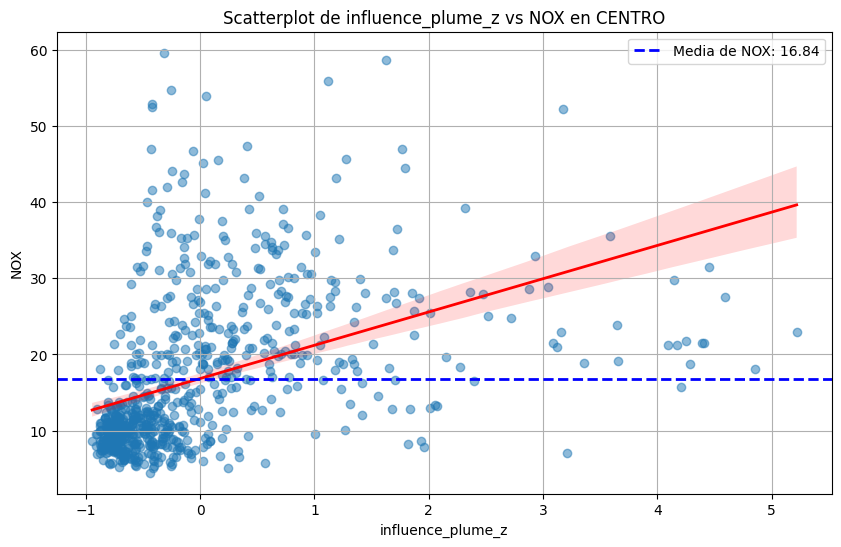

In [15]:
plot_centros_candidate_v_contamintant(df_sima_union_candidato, 'influence_plume_z', 'NOX')

In [22]:
df_sima_union_candidato

date_only,Hora,Zona,CO,NOX,O3,PM2.5,PM10,WSR,WDR,date,hour,influence_plume_sum,influence_plume_log1p_sum,Q_hat_mean,u_mean,wind_cov,influence_plume_z
str,i64,str,f64,f64,f64,f64,f64,f64,f64,date,i64,f64,f64,f64,f64,f64,f64
"""2024-08-01""",0,"""CENTRO""",0.4841826,8.767834,16.384539,32.805374,88.79609,9.015996,85.00341,2024-08-01,0,1799.904498,1369.525861,7.439061,9.015996,1.0,-0.44696
"""2024-08-01""",0,"""NORTE""",0.9056643,8.050037,13.299111,22.510893,78.0,9.597399,171.84186,2024-08-01,0,2960.112531,2179.32585,9.054448,9.597399,1.0,-0.393152
"""2024-08-01""",0,"""SURESTE""",0.623575,7.507266,18.192194,22.631094,91.57979,15.822094,110.56041,2024-08-01,0,1497.123974,1214.496418,8.668409,15.822094,1.0,-0.650135
"""2024-08-01""",1,"""CENTRO""",0.58,15.6,13.0,39.149998,94.0,8.0,47.999996,2024-08-01,1,2166.854644,1598.484372,7.649177,8.0,1.0,-0.253922
"""2024-08-01""",1,"""NORTE""",0.9464729,7.5113125,14.000001,20.661089,69.0,7.2000003,150.0,2024-08-01,1,3984.639315,2744.413444,9.117754,7.2000003,1.0,-0.124785
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2024-08-31""",22,"""NORTE""",1.409713,24.199999,16.0,18.409334,25.999998,4.7,81.0,2024-08-31,22,5041.139547,3031.924727,8.854241,4.7,1.0,0.151958
"""2024-08-31""",22,"""SURESTE""",1.54,45.5,4.0,6.6899986,42.0,4.2999997,159.0,2024-08-31,22,3412.340115,1993.600136,8.502695,4.2999997,1.0,0.248262
"""2024-08-31""",23,"""CENTRO""",1.1500001,20.1,12.000002,13.86,36.0,3.8,86.0,2024-08-31,23,4157.379167,2562.11152,7.351705,3.8,1.0,0.793219


In [24]:
df_sima_union_candidato.write_csv("data/processed/df_sima_union_pluma_gaussiana.csv")